# From Fraud Prediction to Business Action
### Episodic, memory-safe pipeline (IEEE-CIS primary · PaySim secondary)

| Episode | What | Output |
|---------|------|--------|
| **0** | Setup + CONFIG | — |
| **A** | Load + behavioral features → parquet | `ieee_feat.parquet` |
| **B** | Split + LightGBM E1–E4 + save proba | metrics CSVs, `proba_test.npy` |
| **C** | SHAP + E6 cost policy + E7a budgets | plots |
| **D** | PaySim fraud-enriched validation | PaySim metrics |
| **E** | Results JSON | `experiment_results_summary.json` |

**Rules:** temporal split · causal behavioral features · oversample TRAIN only · E6 costs = hypothetical sensitivity analysis.

**How to run:** A → (optional restart) → 0 → B → C → D → E. For paper full data set `SAMPLE_N_IEEE = None` on high-RAM.


## Episode 0 — Setup


In [1]:
import os, gc, json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score, roc_auc_score, precision_score,
    recall_score, f1_score, matthews_corrcoef, precision_recall_curve,
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not available")

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("lightgbm not available")

try:
    from imblearn.over_sampling import RandomOverSampler, SMOTE
    HAS_IMBLEARN = True
except ImportError:
    HAS_IMBLEARN = False
    print("imbalanced-learn not available")

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("shap not available")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def rss_mb():
    try:
        with open("/proc/self/status") as f:
            for line in f:
                if line.startswith("VmRSS:"):
                    return int(line.split()[1]) / 1024.0
    except Exception:
        pass
    return -1.0

print(f"RSS={rss_mb():.0f} MB")


RSS=446 MB


In [2]:
CONFIG = {
    "ieee_transaction_path": "/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv",
    "ieee_identity_path":    "/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv",
    "paysim_path":           "/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv",

    # Safe default for ~13-16GB. Paper numbers: None on 30GB+ RAM.
    "SAMPLE_N_IEEE": 200_000,
    "SAMPLE_N_PAYSIM_FRAUD_MULT": 80,  # all fraud + this x legit

    "train_frac": 0.60,
    "val_frac":   0.20,
    "test_frac":  0.20,

    "entity_col_ieee": "card1",
    "velocity_windows_ieee": [3600 * h for h in [1, 6, 24, 168]],
    "velocity_windows_paysim": [1, 6, 24],

    "drop_high_missing": True,
    "high_missing_threshold": 0.90,
    "full_run_lgbm_only": True,

    "output_dir": "/kaggle/working/outputs",
    "feat_parquet": "/kaggle/working/outputs/ieee_feat.parquet",
    "proba_path": "/kaggle/working/outputs/proba_test_ieee.npy",
    "y_test_path": "/kaggle/working/outputs/y_test_ieee.npy",
}
os.makedirs(CONFIG["output_dir"], exist_ok=True)
print(json.dumps({k: v for k, v in CONFIG.items() if "path" not in k}, indent=2))
print(f"RSS={rss_mb():.0f} MB")


{
  "SAMPLE_N_IEEE": 200000,
  "SAMPLE_N_PAYSIM_FRAUD_MULT": 80,
  "train_frac": 0.6,
  "val_frac": 0.2,
  "test_frac": 0.2,
  "entity_col_ieee": "card1",
  "velocity_windows_ieee": [
    3600,
    21600,
    86400,
    604800
  ],
  "velocity_windows_paysim": [
    1,
    6,
    24
  ],
  "drop_high_missing": true,
  "high_missing_threshold": 0.9,
  "full_run_lgbm_only": true,
  "output_dir": "/kaggle/working/outputs",
  "feat_parquet": "/kaggle/working/outputs/ieee_feat.parquet"
}
RSS=446 MB


## Episode A — Load IEEE + behavioral features → parquet

After this finishes, **Restart kernel** if RSS is high, then re-run Episode 0 and continue to B.


In [3]:
def downcast_df(df):
    for c in df.select_dtypes(include=["float64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="float")
    for c in df.select_dtypes(include=["int64"]).columns:
        df[c] = pd.to_numeric(df[c], downcast="integer")
    return df

def load_ieee(config):
    t0 = time.time()
    trans_path = Path(config["ieee_transaction_path"])
    ident_path = Path(config["ieee_identity_path"])
    assert trans_path.exists(), f"Not found: {trans_path}"
    nrows = config["SAMPLE_N_IEEE"]
    print(f"[A] Loading transaction (nrows={nrows})...", flush=True)
    df_trans = pd.read_csv(trans_path, nrows=nrows)
    df_trans = downcast_df(df_trans)
    print(f"  trans={df_trans.shape}  RSS={rss_mb():.0f} MB", flush=True)

    if ident_path.exists():
        print("[A] Loading identity (filtered to sampled IDs)...", flush=True)
        ids = set(df_trans["TransactionID"].values)
        chunks = []
        for chunk in pd.read_csv(ident_path, chunksize=200_000):
            chunk = chunk[chunk["TransactionID"].isin(ids)]
            if len(chunk):
                chunks.append(chunk)
        if chunks:
            df_ident = downcast_df(pd.concat(chunks, ignore_index=True))
            df = df_trans.merge(df_ident, on="TransactionID", how="left")
            del df_ident, chunks
        else:
            df = df_trans
        del df_trans
        gc.collect()
    else:
        df = df_trans

    if config.get("drop_high_missing", False):
        thr = config.get("high_missing_threshold", 0.90)
        miss = df.isna().mean()
        protect = {"isFraud", "TransactionID", "TransactionDT", "TransactionAmt", config["entity_col_ieee"]}
        drop_cols = [c for c in miss.index if miss[c] > thr and c not in protect]
        if drop_cols:
            print(f"  Dropping {len(drop_cols)} cols with >{thr:.0%} missing", flush=True)
            df = df.drop(columns=drop_cols)

    df = df.sort_values("TransactionDT").reset_index(drop=True)
    df = downcast_df(df)
    print(f"[A] IEEE loaded: {df.shape[0]:,} x {df.shape[1]} in {time.time()-t0:.1f}s  RSS={rss_mb():.0f} MB")
    return df

df_ieee = load_ieee(CONFIG)
print("Fraud rate:", f"{df_ieee['isFraud'].mean()*100:.3f}%")


[A] Loading transaction (nrows=200000)...
  trans=(200000, 394)  RSS=767 MB
[A] Loading identity (filtered to sampled IDs)...
  Dropping 11 cols with >90% missing
[A] IEEE loaded: 200,000 x 423 in 13.5s  RSS=1156 MB
Fraud rate: 3.012%


In [4]:
def add_behavioral_features_ieee(df, entity_col, amount_col, time_col, windows_seconds, eps=1e-6):
    t_all = time.time()
    df = df.sort_values(time_col).reset_index(drop=True)
    print(f"  [beh] sorted rows={len(df):,}  RSS={rss_mb():.0f} MB", flush=True)
    g = df.groupby(entity_col, sort=False)

    df["beh_prev_tx_count"] = g.cumcount()
    shifted = g[amount_col].shift(1)
    past_cnt = df["beh_prev_tx_count"].astype(np.float32)
    past_sum = shifted.fillna(0.0).groupby(df[entity_col], sort=False).cumsum()
    df["beh_prev_amount_mean"] = np.where(past_cnt > 0, past_sum / past_cnt, np.nan).astype(np.float32)

    shifted_sq = shifted ** 2
    past_sum_sq = shifted_sq.fillna(0.0).groupby(df[entity_col], sort=False).cumsum()
    mean_sq = np.where(past_cnt > 0, past_sum_sq / past_cnt, np.nan)
    var = np.maximum(mean_sq - df["beh_prev_amount_mean"].astype(np.float64) ** 2, 0.0)
    df["beh_prev_amount_std"] = np.sqrt(var).astype(np.float32)
    df["beh_prev_amount_std"] = df["beh_prev_amount_std"].fillna(0.0)
    print(f"  [beh] mean/std done  RSS={rss_mb():.0f} MB", flush=True)

    df["beh_amount_zscore"] = ((df[amount_col] - df["beh_prev_amount_mean"]) / (df["beh_prev_amount_std"] + eps)).astype(np.float32)
    df["beh_amount_ratio"] = (df[amount_col] / (df["beh_prev_amount_mean"] + eps)).astype(np.float32)
    first = df["beh_prev_tx_count"] == 0
    df.loc[first, ["beh_amount_zscore", "beh_amount_ratio"]] = 0.0
    df["beh_amount_ratio"] = df["beh_amount_ratio"].replace([np.inf, -np.inf], np.nan)
    med = df["beh_amount_ratio"].median()
    df["beh_amount_ratio"] = df["beh_amount_ratio"].fillna(med if pd.notna(med) else 1.0)

    df["beh_time_since_prev"] = (df[time_col] - g[time_col].shift(1)).astype(np.float32)
    mx = df["beh_time_since_prev"].max()
    df["beh_time_since_prev"] = df["beh_time_since_prev"].fillna(mx if pd.notna(mx) else 0)

    print("  [beh] velocity...", flush=True)
    entities = df[entity_col].fillna("__NA__").values
    times = df[time_col].values
    order = np.argsort(entities, kind="stable")
    ent_vals, t_vals = entities[order], times[order]
    for wi, w in enumerate(windows_seconds):
        counts = np.zeros(len(df), dtype=np.int32)
        n, i = len(df), 0
        while i < n:
            j = i
            while j < n and ent_vals[j] == ent_vals[i]:
                j += 1
            sub_t = t_vals[i:j]
            lo = 0
            for k in range(len(sub_t)):
                cutoff = sub_t[k] - w
                while lo < k and sub_t[lo] < cutoff:
                    lo += 1
                counts[i + k] = k - lo
            i = j
        tmp = np.empty(len(df), dtype=np.int32)
        tmp[order] = counts
        df[f"beh_velocity_{w}s"] = tmp
        print(f"  [beh] window {w}s ({wi+1}/{len(windows_seconds)})", flush=True)

    print(f"  [beh] DONE in {time.time()-t_all:.1f}s  shape={df.shape}  RSS={rss_mb():.0f} MB", flush=True)
    return df

print("[A] Building behavioral features...", flush=True)
df_ieee_feat = add_behavioral_features_ieee(
    df_ieee,
    entity_col=CONFIG["entity_col_ieee"],
    amount_col="TransactionAmt",
    time_col="TransactionDT",
    windows_seconds=CONFIG["velocity_windows_ieee"],
)
del df_ieee
gc.collect()

GROUP3_COLS = [c for c in df_ieee_feat.columns if c.startswith("beh_")]
print("Group3:", GROUP3_COLS)

feat_path = CONFIG["feat_parquet"]
df_ieee_feat.to_parquet(feat_path, index=False)
print(f"[A] Saved {feat_path}  rows={len(df_ieee_feat):,}  RSS={rss_mb():.0f} MB")
print(">>> Episode A complete. Restart kernel before B if RAM is tight.")


[A] Building behavioral features...
  [beh] sorted rows=200,000  RSS=1498 MB
  [beh] mean/std done  RSS=1499 MB
  [beh] velocity...
  [beh] window 3600s (1/4)
  [beh] window 21600s (2/4)
  [beh] window 86400s (3/4)
  [beh] window 604800s (4/4)
  [beh] DONE in 1.2s  shape=(200000, 433)  RSS=1499 MB
Group3: ['beh_prev_tx_count', 'beh_prev_amount_mean', 'beh_prev_amount_std', 'beh_amount_zscore', 'beh_amount_ratio', 'beh_time_since_prev', 'beh_velocity_3600s', 'beh_velocity_21600s', 'beh_velocity_86400s', 'beh_velocity_604800s']
[A] Saved /kaggle/working/outputs/ieee_feat.parquet  rows=200,000  RSS=1245 MB
>>> Episode A complete. Restart kernel before B if RAM is tight.


## Episode B — Split + models E1–E4 + save proba

Re-run **Episode 0** after restart, then this section. Loads parquet from A.


In [5]:
feat_path = CONFIG["feat_parquet"]
assert Path(feat_path).exists(), f"Run Episode A first: missing {feat_path}"
print(f"[B] Loading {feat_path}...", flush=True)
df_ieee_feat = pd.read_parquet(feat_path)
print(f"  shape={df_ieee_feat.shape}  RSS={rss_mb():.0f} MB", flush=True)

GROUP3_COLS = [c for c in df_ieee_feat.columns if c.startswith("beh_")]

def build_feature_groups(df):
    cols = df.columns.tolist()
    core = [c for c in [
        "TransactionAmt", "ProductCD",
        "card1", "card2", "card3", "card4", "card5", "card6",
        "addr1", "addr2", "dist1", "dist2",
        "P_emaildomain", "R_emaildomain",
    ] if c in cols]
    group_c = [c for c in cols if c.startswith("C") and c[1:].isdigit()]
    group_d = [c for c in cols if c.startswith("D") and c[1:].isdigit()]
    group_v = [c for c in cols if c.startswith("V") and c[1:].isdigit()]
    group_m = [c for c in cols if c.startswith("M") and c[1:].isdigit()]
    return {
        "core": core,
        "existing_behavioral": group_c + group_d + group_v + group_m,
        "engineered_behavioral": [c for c in cols if c.startswith("beh_")],
    }

FEATURE_GROUPS = build_feature_groups(df_ieee_feat)
for k, v in FEATURE_GROUPS.items():
    print(f"  {k:25s}: {len(v):4d}")


[B] Loading /kaggle/working/outputs/ieee_feat.parquet...
  shape=(200000, 433)  RSS=1229 MB
  core                     :   13
  existing_behavioral      :  376
  engineered_behavioral    :   10


In [6]:
def temporal_split(df, time_col, train_frac, val_frac, test_frac):
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-6
    df = df.sort_values(time_col).reset_index(drop=True)
    n = len(df)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)
    train_df = df.iloc[:n_train].copy()
    val_df = df.iloc[n_train:n_train + n_val].copy()
    test_df = df.iloc[n_train + n_val:].copy()
    for name, d in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
        print(f"  {name}: {len(d):,}  fraud={d['isFraud'].mean()*100:.3f}%")
    return train_df, val_df, test_df

print("[B] Temporal split...")
ieee_train, ieee_val, ieee_test = temporal_split(
    df_ieee_feat, "TransactionDT",
    CONFIG["train_frac"], CONFIG["val_frac"], CONFIG["test_frac"],
)
del df_ieee_feat
gc.collect()
print(f"RSS={rss_mb():.0f} MB")


[B] Temporal split...
  Train: 120,000  fraud=2.392%
  Val: 40,000  fraud=3.740%
  Test: 40,000  fraud=4.145%
RSS=1545 MB


In [7]:
def get_dtype_split(df, feature_cols):
    cat_cols = [c for c in feature_cols if df[c].dtype == "object" or str(df[c].dtype) == "category"]
    num_cols = [c for c in feature_cols if c not in cat_cols]
    return cat_cols, num_cols

class SimplePreprocessor:
    def __init__(self, feature_cols, missing_flag_threshold=0.5):
        self.feature_cols = feature_cols
        self.missing_flag_threshold = missing_flag_threshold
        self.freq_maps, self.medians = {}, {}
        self.flag_cols, self.cat_cols, self.num_cols = [], [], []

    def fit(self, df_train):
        present = [c for c in self.feature_cols if c in df_train.columns]
        self.feature_cols = present
        self.cat_cols, self.num_cols = get_dtype_split(df_train, self.feature_cols)
        miss = df_train[self.feature_cols].isna().mean()
        self.flag_cols = miss[miss > self.missing_flag_threshold].index.tolist()
        for c in self.cat_cols:
            self.freq_maps[c] = df_train[c].astype(str).value_counts(normalize=True).to_dict()
        for c in self.num_cols:
            self.medians[c] = float(df_train[c].median()) if df_train[c].notna().any() else 0.0
        return self

    def transform(self, df):
        n = len(df)
        cols = {}
        for c in self.flag_cols:
            cols[f"{c}_was_missing"] = df[c].isna().astype(np.float32).values if c in df.columns else np.zeros(n, np.float32)
        for c in self.cat_cols:
            freq = self.freq_maps.get(c, {})
            cols[c] = df[c].astype(str).map(freq).fillna(0.0).astype(np.float32).values if c in df.columns else np.zeros(n, np.float32)
        for c in self.num_cols:
            med = self.medians.get(c, 0.0)
            cols[c] = df[c].fillna(med).astype(np.float32).values if c in df.columns else np.full(n, med, np.float32)
        return pd.DataFrame(cols, index=df.index)

def make_xy(train_df, val_df, test_df, feature_cols, target_col="isFraud", scale=False):
    feature_cols = [c for c in feature_cols if c in train_df.columns]
    print(f"[make_xy] n_feat={len(feature_cols)} scale={scale} RSS={rss_mb():.0f}", flush=True)
    prep = SimplePreprocessor(feature_cols).fit(train_df)
    X_train = prep.transform(train_df)
    X_val = prep.transform(val_df)
    X_test = prep.transform(test_df)
    y_train = train_df[target_col].values
    y_val = val_df[target_col].values
    y_test = test_df[target_col].values
    if scale:
        scaler = StandardScaler()
        X_train = pd.DataFrame(scaler.fit_transform(X_train).astype(np.float32), columns=X_train.columns, index=X_train.index)
        X_val = pd.DataFrame(scaler.transform(X_val).astype(np.float32), columns=X_val.columns, index=X_val.index)
        X_test = pd.DataFrame(scaler.transform(X_test).astype(np.float32), columns=X_test.columns, index=X_test.index)
    print(f"  shapes {X_train.shape} {X_val.shape} {X_test.shape} RSS={rss_mb():.0f}", flush=True)
    return X_train, y_train, X_val, y_val, X_test, y_test, prep

def evaluate(y_true, y_proba, threshold=0.5, label=""):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "label": label,
        "PR_AUC": float(average_precision_score(y_true, y_proba)),
        "ROC_AUC": float(roc_auc_score(y_true, y_proba)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "MCC": float(matthews_corrcoef(y_true, y_pred)),
    }

results_log = []
print("Helpers ready  RSS={:.0f} MB".format(rss_mb()))


Helpers ready  RSS=1545 MB


In [8]:
# E1 model comparison (LGBM-only if full_run_lgbm_only)
BASELINE_FEATURES = [c for c in (FEATURE_GROUPS["core"] + FEATURE_GROUPS["existing_behavioral"]) if c in ieee_train.columns]
X_train, y_train, X_val, y_val, X_test, y_test, _ = make_xy(
    ieee_train, ieee_val, ieee_test, BASELINE_FEATURES, scale=False
)
pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
lgbm_only = CONFIG.get("full_run_lgbm_only", True)

models = {}
if not lgbm_only:
    models["M2_RandomForest"] = RandomForestClassifier(
        n_estimators=120, max_depth=10, min_samples_leaf=20,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, max_features="sqrt"
    )
    if HAS_XGB:
        models["M3_XGBoost"] = xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
            eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"
        )
if HAS_LGB:
    models["M4_LightGBM"] = lgb.LGBMClassifier(
        n_estimators=400, num_leaves=63, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_weight,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )

print(f"[E1] models={list(models)}  lgbm_only={lgbm_only}")
e1_rows, fitted = [], {}
for name, model in models.items():
    print(f"\n[E1] Fitting {name}...", flush=True)
    t0 = time.time()
    model.fit(X_train, y_train)
    ft = time.time() - t0
    pv = model.predict_proba(X_val)[:, 1]
    pt = model.predict_proba(X_test)[:, 1]
    mv = evaluate(y_val, pv, label=f"E1_{name}_VAL")
    mt = evaluate(y_test, pt, label=f"E1_{name}_TEST")
    mv["fit_time_s"] = mt["fit_time_s"] = round(ft, 1)
    e1_rows += [mv, mt]
    fitted[name] = model
    print(f"  VAL PR-AUC={mv['PR_AUC']:.4f}  TEST PR-AUC={mt['PR_AUC']:.4f}  ({ft:.1f}s)")
    gc.collect()

df_e1 = pd.DataFrame(e1_rows)
results_log.append(df_e1)
best_model_name = (
    df_e1[df_e1.label.str.contains("_VAL")]
    .assign(base=lambda d: d.label.str.replace("E1_", "").str.replace("_VAL", ""))
    .sort_values("PR_AUC", ascending=False)
    .iloc[0]["base"]
)
print("Best on VAL PR-AUC:", best_model_name)
df_e1


[make_xy] n_feat=389 scale=False RSS=1545
  shapes (120000, 579) (40000, 579) (40000, 579) RSS=1987
[E1] models=['M4_LightGBM']  lgbm_only=True

[E1] Fitting M4_LightGBM...
  VAL PR-AUC=0.5666  TEST PR-AUC=0.5087  (27.2s)
Best on VAL PR-AUC: M4_LightGBM


,label,PR_AUC,ROC_AUC,Precision,Recall,F1,MCC,fit_time_s
0,E1_M4_LightGBM_VAL,0.566630,0.879699,0.476914,0.566176,0.517726,0.499307,27.2
1,E1_M4_LightGBM_TEST,0.508687,0.862751,0.487291,0.474065,0.480587,0.458496,27.2


In [9]:
# E2 behavioral enrichment
def fit_champion(name, Xtr, ytr, Xva, Xte):
    pos_w = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
    if name == "M4_LightGBM" and HAS_LGB:
        model = lgb.LGBMClassifier(
            n_estimators=400, num_leaves=63, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_w,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
        )
    elif name == "M3_XGBoost" and HAS_XGB:
        model = xgb.XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=pos_w,
            eval_metric="aucpr", random_state=RANDOM_STATE, n_jobs=-1, tree_method="hist"
        )
    else:
        model = RandomForestClassifier(
            n_estimators=120, max_depth=10, class_weight="balanced",
            random_state=RANDOM_STATE, n_jobs=-1
        )
    model.fit(Xtr, ytr)
    return model, model.predict_proba(Xva)[:, 1], model.predict_proba(Xte)[:, 1]

feature_sets_e2 = {
    "ModelA_core_only": FEATURE_GROUPS["core"],
    "ModelB_core_plus_existing": FEATURE_GROUPS["core"] + FEATURE_GROUPS["existing_behavioral"],
    "ModelC_core_existing_engineered": (
        FEATURE_GROUPS["core"] + FEATURE_GROUPS["existing_behavioral"] + FEATURE_GROUPS["engineered_behavioral"]
    ),
}

e2_rows = []
for fs_name, cols in feature_sets_e2.items():
    cols = [c for c in cols if c in ieee_train.columns]
    Xtr, ytr, Xva, yva, Xte, yte, _ = make_xy(ieee_train, ieee_val, ieee_test, cols, scale=False)
    model, pv, pt = fit_champion(best_model_name, Xtr, ytr, Xva, Xte)
    e2_rows += [evaluate(yva, pv, label=f"E2_{fs_name}_VAL"), evaluate(yte, pt, label=f"E2_{fs_name}_TEST")]
    print(f"E2 {fs_name:35s} n={len(cols):4d}  TEST PR-AUC={e2_rows[-1]['PR_AUC']:.4f}")
    del Xtr, Xva, Xte
    gc.collect()

df_e2 = pd.DataFrame(e2_rows)
results_log.append(df_e2)
tr = df_e2[df_e2.label.str.contains("_TEST")].copy()
tr["fs"] = tr.label.str.replace("E2_", "").str.replace("_TEST", "")
pr_b = tr.loc[tr.fs == "ModelB_core_plus_existing", "PR_AUC"].values[0]
pr_c = tr.loc[tr.fs == "ModelC_core_existing_engineered", "PR_AUC"].values[0]
print(f"Delta PR-AUC (C vs B): {pr_c - pr_b:+.4f}")
df_e2


[make_xy] n_feat=13 scale=False RSS=2545
  shapes (120000, 15) (40000, 15) (40000, 15) RSS=2545
E2 ModelA_core_only                    n=  13  TEST PR-AUC=0.2497
[make_xy] n_feat=389 scale=False RSS=2545
  shapes (120000, 579) (40000, 579) (40000, 579) RSS=2691
E2 ModelB_core_plus_existing           n= 389  TEST PR-AUC=0.5087
[make_xy] n_feat=399 scale=False RSS=2905
  shapes (120000, 589) (40000, 589) (40000, 589) RSS=2918
E2 ModelC_core_existing_engineered     n= 399  TEST PR-AUC=0.5247
Delta PR-AUC (C vs B): +0.0160


,label,PR_AUC,ROC_AUC,Precision,Recall,F1,MCC
0,E2_ModelA_core_only_VAL,0.225335,0.788697,0.176736,0.471257,0.257065,0.244410
1,E2_ModelA_core_only_TEST,0.249729,0.758334,0.211840,0.399276,0.276814,0.248848
2,E2_ModelB_core_plus_existing_VAL,0.566630,0.879699,0.476914,0.566176,0.517726,0.499307
3,E2_ModelB_core_plus_existing_TEST,0.508687,0.862751,0.487291,0.474065,0.480587,0.458496
4,E2_ModelC_core_existing_engineered_VAL,0.572534,0.885330,0.588367,0.527406,0.556221,0.540824
5,E2_ModelC_core_existing_engineered_TEST,0.524677,0.877681,0.647810,0.428227,0.515614,0.510586


In [10]:
# E3 imbalance
best_feature_set = [c for c in feature_sets_e2["ModelC_core_existing_engineered"] if c in ieee_train.columns]
Xtr, ytr, Xva, yva, Xte, yte, _ = make_xy(ieee_train, ieee_val, ieee_test, best_feature_set, scale=False)
e3_rows = []
model, pv, pt = fit_champion(best_model_name, Xtr, ytr, Xva, Xte)
e3_rows += [evaluate(yva, pv, label="E3_none_VAL"), evaluate(yte, pt, label="E3_none_TEST")]

if HAS_IMBLEARN:
    ros = RandomOverSampler(random_state=RANDOM_STATE)
    Xtr_r, ytr_r = ros.fit_resample(Xtr, ytr)
    model, pv, pt = fit_champion(best_model_name, Xtr_r, ytr_r, Xva, Xte)
    e3_rows += [evaluate(yva, pv, label="E3_random_oversample_VAL"), evaluate(yte, pt, label="E3_random_oversample_TEST")]
    del Xtr_r, ytr_r
    gc.collect()
    smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
    Xtr_s, ytr_s = smote.fit_resample(Xtr, ytr)
    model, pv, pt = fit_champion(best_model_name, Xtr_s, ytr_s, Xva, Xte)
    e3_rows += [evaluate(yva, pv, label="E3_smote_VAL"), evaluate(yte, pt, label="E3_smote_TEST")]
    del Xtr_s, ytr_s
    gc.collect()
else:
    print("imbalanced-learn missing — skip ROS/SMOTE")

df_e3 = pd.DataFrame(e3_rows)
results_log.append(df_e3)
df_e3


[make_xy] n_feat=399 scale=False RSS=3035
  shapes (120000, 589) (40000, 589) (40000, 589) RSS=3088


,label,PR_AUC,ROC_AUC,Precision,Recall,F1,MCC
0,E3_none_VAL,0.572534,0.885330,0.588367,0.527406,0.556221,0.540824
1,E3_none_TEST,0.524677,0.877681,0.647810,0.428227,0.515614,0.510586
2,E3_random_oversample_VAL,0.576026,0.884379,0.589051,0.539439,0.563154,0.547525
3,E3_random_oversample_TEST,0.523578,0.862293,0.642546,0.444511,0.525490,0.518136
4,E3_smote_VAL,0.615602,0.903706,0.892913,0.379011,0.532145,0.572664
5,E3_smote_TEST,0.558909,0.885226,0.932836,0.301568,0.455789,0.521168


In [11]:
# E4 ablation
velocity_cols = [c for c in GROUP3_COLS if "velocity" in c]
amount_stat_cols = [c for c in GROUP3_COLS if c in ("beh_prev_amount_mean", "beh_prev_amount_std")]
deviation_cols = [c for c in GROUP3_COLS if c in ("beh_amount_zscore", "beh_amount_ratio")]
recency_cols = [c for c in GROUP3_COLS if c == "beh_time_since_prev"]
base_cols = FEATURE_GROUPS["core"] + FEATURE_GROUPS["existing_behavioral"]

ablations = {
    "A1_without_velocity": base_cols + [c for c in GROUP3_COLS if c not in velocity_cols],
    "A2_without_amount_stats": base_cols + [c for c in GROUP3_COLS if c not in amount_stat_cols],
    "A3_without_deviation": base_cols + [c for c in GROUP3_COLS if c not in deviation_cols],
    "A4_without_recency": base_cols + [c for c in GROUP3_COLS if c not in recency_cols],
    "A5_full_model": base_cols + GROUP3_COLS,
}

e4_rows = []
for abl_name, cols in ablations.items():
    cols = [c for c in cols if c in ieee_train.columns]
    Xtr, ytr, Xva, yva, Xte, yte, _ = make_xy(ieee_train, ieee_val, ieee_test, cols, scale=False)
    model, pv, pt = fit_champion(best_model_name, Xtr, ytr, Xva, Xte)
    m = evaluate(yte, pt, label=f"E4_{abl_name}_TEST")
    e4_rows.append(m)
    print(f"{abl_name:28s} TEST PR-AUC={m['PR_AUC']:.4f}  MCC={m['MCC']:.4f}")
    del Xtr, Xva, Xte, model
    gc.collect()

df_e4 = pd.DataFrame(e4_rows)
results_log.append(df_e4)
df_e4


[make_xy] n_feat=395 scale=False RSS=4719
  shapes (120000, 585) (40000, 585) (40000, 585) RSS=4729
A1_without_velocity          TEST PR-AUC=0.5129  MCC=0.4843
[make_xy] n_feat=397 scale=False RSS=3104
  shapes (120000, 587) (40000, 587) (40000, 587) RSS=3104
A2_without_amount_stats      TEST PR-AUC=0.5238  MCC=0.5096
[make_xy] n_feat=397 scale=False RSS=3104
  shapes (120000, 587) (40000, 587) (40000, 587) RSS=3104
A3_without_deviation         TEST PR-AUC=0.5268  MCC=0.5123
[make_xy] n_feat=398 scale=False RSS=3104
  shapes (120000, 588) (40000, 588) (40000, 588) RSS=3104
A4_without_recency           TEST PR-AUC=0.5288  MCC=0.5235
[make_xy] n_feat=399 scale=False RSS=3104
  shapes (120000, 589) (40000, 589) (40000, 589) RSS=3104
A5_full_model                TEST PR-AUC=0.5247  MCC=0.5106


,label,PR_AUC,ROC_AUC,Precision,Recall,F1,MCC
0,E4_A1_without_velocity_TEST,0.512874,0.866767,0.580983,0.434861,0.497413,0.484337
1,E4_A2_without_amount_stats_TEST,0.523826,0.870572,0.637168,0.434258,0.516499,0.509569
2,E4_A3_without_deviation_TEST,0.526764,0.874062,0.645946,0.432449,0.518064,0.512349
3,E4_A4_without_recency_TEST,0.528785,0.869773,0.673258,0.431242,0.525735,0.523469
4,E4_A5_full_model_TEST,0.524677,0.877681,0.647810,0.428227,0.515614,0.510586


In [12]:
# Final model + save proba for Episode C
final_cols = [c for c in (
    FEATURE_GROUPS["core"] + FEATURE_GROUPS["existing_behavioral"] + GROUP3_COLS
) if c in ieee_train.columns]

X_train_f, y_train_f, X_val_f, y_val_f, X_test_f, y_test_f, prep_final = make_xy(
    ieee_train, ieee_val, ieee_test, final_cols, scale=False
)
final_model, proba_val_final, proba_test_final = fit_champion(
    best_model_name, X_train_f, y_train_f, X_val_f, X_test_f
)
final_metrics_test = evaluate(y_test_f, proba_test_final, label="FINAL_MODEL_TEST")
print(final_metrics_test)

np.save(CONFIG["proba_path"], proba_test_final)
np.save(CONFIG["y_test_path"], y_test_f)

df_e1.to_csv(f"{CONFIG['output_dir']}/E1_model_comparison.csv", index=False)
df_e2.to_csv(f"{CONFIG['output_dir']}/E2_behavioral_enrichment.csv", index=False)
df_e3.to_csv(f"{CONFIG['output_dir']}/E3_imbalance_handling.csv", index=False)
df_e4.to_csv(f"{CONFIG['output_dir']}/E4_behavioral_ablation.csv", index=False)

del X_train_f, X_val_f
gc.collect()
print(f"[B] Saved proba + metrics  RSS={rss_mb():.0f} MB")
print(">>> Episode B complete.")


[make_xy] n_feat=399 scale=False RSS=3104
  shapes (120000, 589) (40000, 589) (40000, 589) RSS=3104
{'label': 'FINAL_MODEL_TEST', 'PR_AUC': 0.5246767714506116, 'ROC_AUC': 0.8776808513864712, 'Precision': 0.6478102189781022, 'Recall': 0.428226779252111, 'F1': 0.5156136528685549, 'MCC': 0.5105863458912074}
[B] Saved proba + metrics  RSS=3186 MB
>>> Episode B complete.


## Episode C — SHAP + E6 Risk-to-Action + E7a budgets

E6/E7a work from saved proba even after restart. SHAP needs `final_model` + `X_test_f` in memory.


In [13]:
if "proba_test_final" not in dir() or proba_test_final is None:
    proba_test_final = np.load(CONFIG["proba_path"])
    y_test_f = np.load(CONFIG["y_test_path"])
    print("Reloaded proba/y_test from disk")
if "final_metrics_test" not in dir():
    final_metrics_test = evaluate(y_test_f, proba_test_final, label="FINAL_MODEL_TEST")
    print(final_metrics_test)


Global |SHAP|:


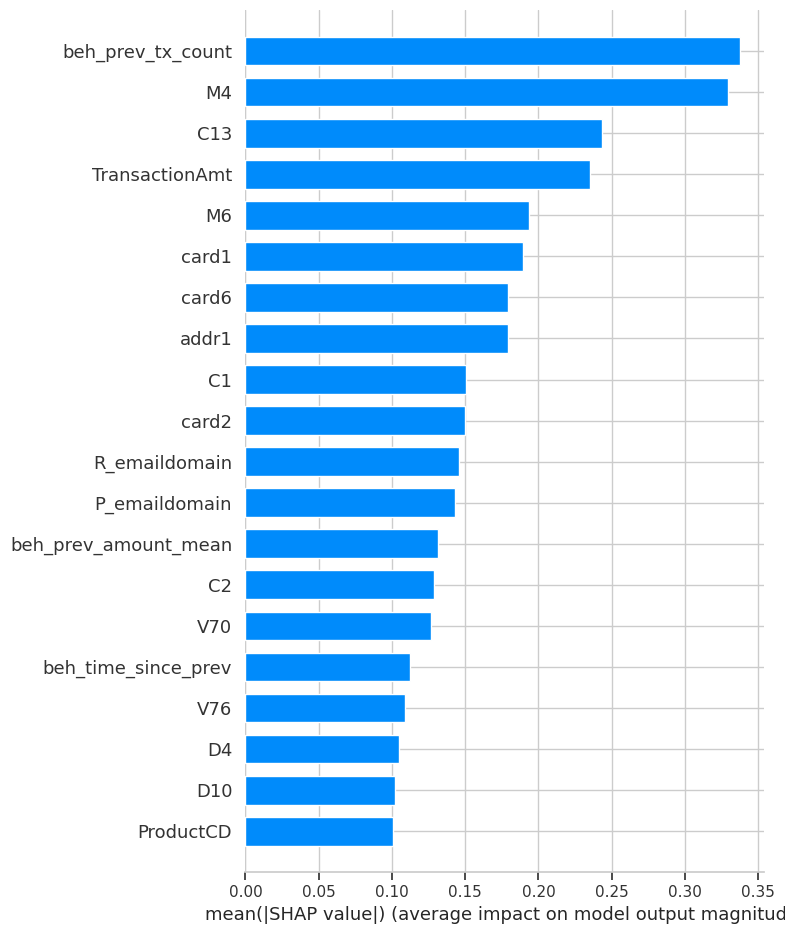

Beeswarm:


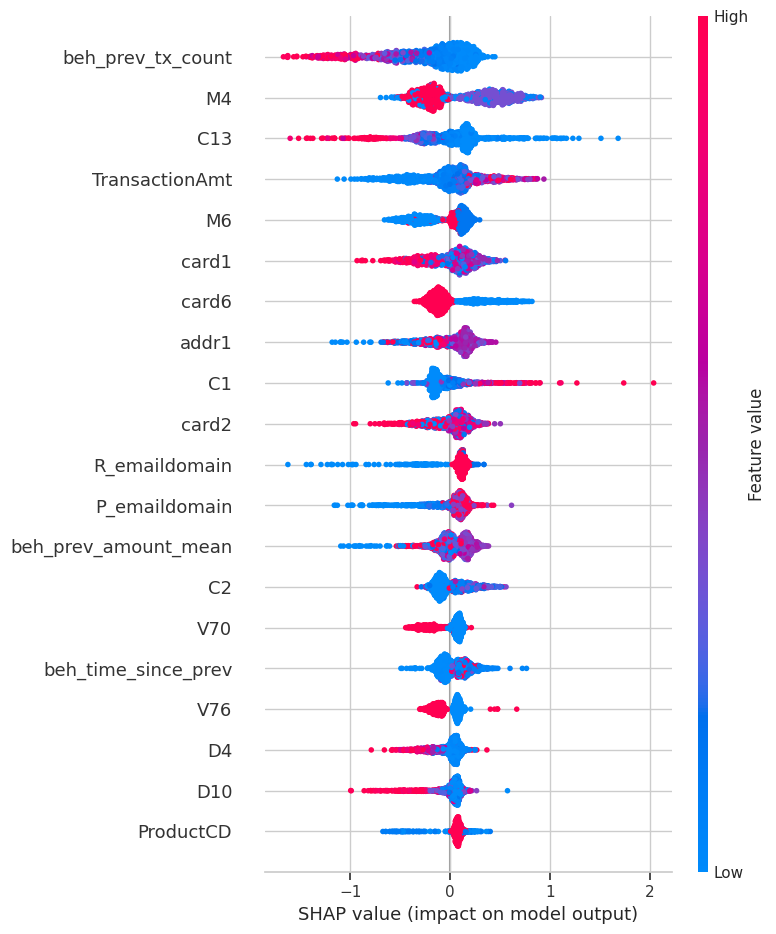


RISK SCORE
1.00
KEY RISK DRIVERS
up V156 (SHAP=+2.130)
up V149 (SHAP=+1.919)
up V198 (SHAP=+1.237)

RECOMMENDED ACTION
BLOCK


In [14]:
# E5 SHAP (optional)
if HAS_SHAP and "final_model" in dir() and "X_test_f" in dir():
    explain_sample = X_test_f.sample(n=min(1500, len(X_test_f)), random_state=RANDOM_STATE)
    try:
        explainer = shap.TreeExplainer(final_model)
        shap_values = explainer.shap_values(explain_sample)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
        print("Global |SHAP|:")
        shap.summary_plot(shap_values, explain_sample, plot_type="bar", show=True)
        print("Beeswarm:")
        shap.summary_plot(shap_values, explain_sample, show=True)
        local_idx = int(np.argmax(final_model.predict_proba(explain_sample)[:, 1]))
        local_proba = float(final_model.predict_proba(explain_sample)[local_idx, 1])
        row = shap_values[local_idx]
        order = np.argsort(-np.abs(row))[:3]
        print("\nRISK SCORE\n{:.2f}".format(local_proba))
        print("KEY RISK DRIVERS")
        for idx in order:
            direction = "up" if row[idx] > 0 else "down"
            print(f"{direction} {explain_sample.columns[idx]} (SHAP={row[idx]:+.3f})")
        action = "APPROVE" if local_proba < 0.3 else ("REVIEW" if local_proba < 0.7 else "BLOCK")
        print(f"\nRECOMMENDED ACTION\n{action}")
    except Exception as e:
        print("SHAP failed:", e)
else:
    print("Skip SHAP (need model + X_test_f). E6/E7a still run from proba.")


S1_fraud_10x: tau1=0.035 tau2=0.868 cost=4960.4 capture=0.859 review_rate=0.325
S2_fraud_25x: tau1=0.010 tau2=0.868 cost=6368.2 capture=0.964 review_rate=0.608
S3_fraud_50x: tau1=0.010 tau2=0.868 cost=7843.2 capture=0.964 review_rate=0.608


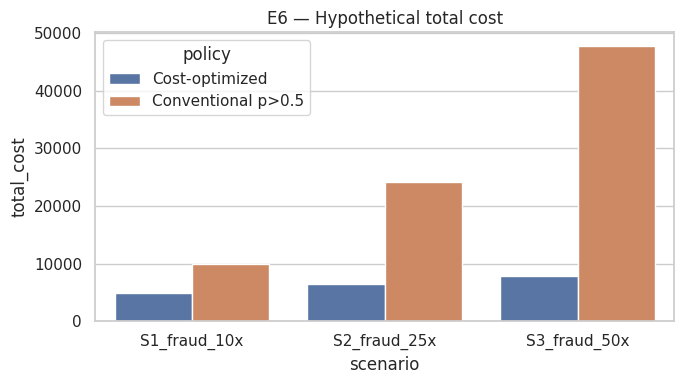

,tau1,tau2,total_cost,fraud_capture,review_rate,false_decline_rate,n_review,scenario
0,0.0345,0.8675,4960.4,0.859469,0.32505,0.000782,13002,S1_fraud_10x
1,0.0100,0.8675,6368.2,0.964415,0.60790,0.000782,24316,S2_fraud_25x
2,0.0100,0.8675,7843.2,0.964415,0.60790,0.000782,24316,S3_fraud_50x


In [15]:
# E6 cost-sensitive policy
def expected_cost(y_true, proba, tau1, tau2, c_fn, c_fp, c_review, amounts=None):
    action = np.where(proba < tau1, "APPROVE", np.where(proba < tau2, "REVIEW", "BLOCK"))
    cost = np.zeros(len(y_true), dtype=float)
    fn_mask = (action == "APPROVE") & (y_true == 1)
    fp_mask = (action == "BLOCK") & (y_true == 0)
    rv_mask = (action == "REVIEW")
    cost[fn_mask] = c_fn
    cost[fp_mask] = c_fp
    cost[rv_mask] = c_review
    return {
        "tau1": float(tau1), "tau2": float(tau2), "total_cost": float(cost.sum()),
        "fraud_capture": float(y_true[action != "APPROVE"].sum() / max(y_true.sum(), 1)),
        "review_rate": float(rv_mask.mean()),
        "false_decline_rate": float(fp_mask.sum() / max((y_true == 0).sum(), 1)),
        "n_review": int(rv_mask.sum()),
    }

def optimize_thresholds(y_true, proba, c_fn, c_fp, c_review, amounts=None, grid=41):
    taus = np.linspace(0.01, 0.99, grid)
    best, rows = None, []
    for tau1 in taus:
        for tau2 in taus:
            if tau2 <= tau1:
                continue
            r = expected_cost(y_true, proba, tau1, tau2, c_fn, c_fp, c_review, amounts)
            rows.append(r)
            if best is None or r["total_cost"] < best["total_cost"]:
                best = r
    return best, pd.DataFrame(rows)

scenarios = {
    "S1_fraud_10x": dict(c_fn=10.0, c_fp=1.0, c_review=0.2),
    "S2_fraud_25x": dict(c_fn=25.0, c_fp=1.0, c_review=0.2),
    "S3_fraud_50x": dict(c_fn=50.0, c_fp=1.0, c_review=0.2),
}

e6_rows, policy1_rows = [], []
for scen_name, costs in scenarios.items():
    best, _ = optimize_thresholds(y_test_f, proba_test_final, **costs)
    best["scenario"] = scen_name
    e6_rows.append(best)
    conv = expected_cost(y_test_f, proba_test_final, tau1=0.5, tau2=0.5 + 1e-9, **costs)
    conv["scenario"] = scen_name
    policy1_rows.append(conv)
    print(f"{scen_name}: tau1={best['tau1']:.3f} tau2={best['tau2']:.3f} "
          f"cost={best['total_cost']:.1f} capture={best['fraud_capture']:.3f} "
          f"review_rate={best['review_rate']:.3f}")

df_e6 = pd.DataFrame(e6_rows)
df_policy1 = pd.DataFrame(policy1_rows)
df_e6.to_csv(f"{CONFIG['output_dir']}/E6_cost_optimization.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
compare = pd.concat([
    df_e6.assign(policy="Cost-optimized"),
    df_policy1.assign(policy="Conventional p>0.5"),
])
sns.barplot(data=compare, x="scenario", y="total_cost", hue="policy", ax=ax)
ax.set_title("E6 — Hypothetical total cost")
plt.tight_layout()
plt.show()
df_e6


Fraud Capture @ Review Budget:
  FC@1%: 0.230
  FC@5%: 0.511
  FC@10%: 0.621


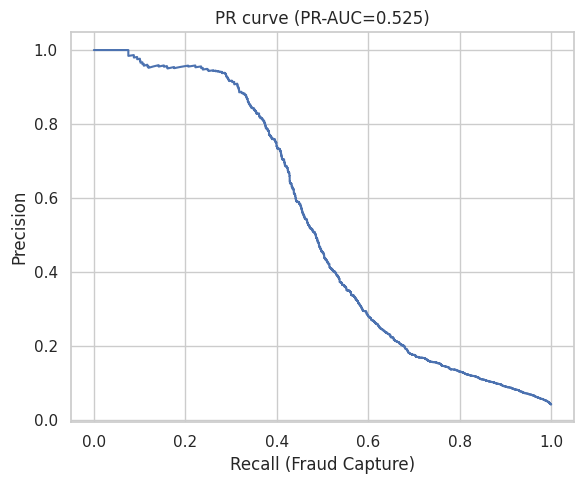

>>> Episode C complete.


In [16]:
# E7a review budgets
def fraud_capture_at_budget(y_true, proba, budget_fracs=(0.01, 0.05, 0.10)):
    order = np.argsort(-proba)
    y_sorted = y_true[order]
    n, total_fraud = len(y_true), y_true.sum()
    out = {}
    for b in budget_fracs:
        k = max(int(np.ceil(n * b)), 1)
        out[f"FC@{int(b*100)}%"] = float(y_sorted[:k].sum() / max(total_fraud, 1))
    return out

fc_budget = fraud_capture_at_budget(y_test_f, proba_test_final)
print("Fraud Capture @ Review Budget:")
for k, v in fc_budget.items():
    print(f"  {k}: {v:.3f}")

precision, recall, _ = precision_recall_curve(y_test_f, proba_test_final)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall, precision)
ax.set_xlabel("Recall (Fraud Capture)")
ax.set_ylabel("Precision")
ax.set_title(f"PR curve (PR-AUC={final_metrics_test['PR_AUC']:.3f})")
plt.tight_layout()
plt.show()
print(">>> Episode C complete.")


## Episode D — PaySim fraud-enriched validation (E7b)

All fraud rows + `SAMPLE_N_PAYSIM_FRAUD_MULT` x legit. Balance columns excluded.


In [17]:
def add_behavioral_features_paysim(df, windows_hours, eps=1e-6):
    t_all = time.time()
    df = df.sort_values("step").reset_index(drop=True)
    g = df.groupby("nameOrig", sort=False)
    df["beh_prev_tx_count"] = g.cumcount()
    shifted = g["amount"].shift(1)
    past_cnt = df["beh_prev_tx_count"].astype(np.float32)
    past_sum = shifted.fillna(0.0).groupby(df["nameOrig"], sort=False).cumsum()
    df["beh_prev_amount_mean"] = np.where(past_cnt > 0, past_sum / past_cnt, np.nan).astype(np.float32)
    shifted_sq = shifted ** 2
    past_sum_sq = shifted_sq.fillna(0.0).groupby(df["nameOrig"], sort=False).cumsum()
    mean_sq = np.where(past_cnt > 0, past_sum_sq / past_cnt, np.nan)
    var = np.maximum(mean_sq - df["beh_prev_amount_mean"].astype(np.float64) ** 2, 0.0)
    df["beh_prev_amount_std"] = np.sqrt(var).astype(np.float32).fillna(0.0)
    df["beh_amount_zscore"] = ((df["amount"] - df["beh_prev_amount_mean"]) / (df["beh_prev_amount_std"] + eps)).astype(np.float32)
    df["beh_amount_ratio"] = (df["amount"] / (df["beh_prev_amount_mean"] + eps)).astype(np.float32)
    first = df["beh_prev_tx_count"] == 0
    df.loc[first, ["beh_amount_zscore", "beh_amount_ratio"]] = 0.0
    df["beh_amount_ratio"] = df["beh_amount_ratio"].replace([np.inf, -np.inf], np.nan)
    med = df["beh_amount_ratio"].median()
    df["beh_amount_ratio"] = df["beh_amount_ratio"].fillna(med if pd.notna(med) else 1.0)
    df["dest_prev_tx_count"] = df.groupby("nameDest", sort=False).cumcount()

    entities = df["nameOrig"].fillna("__NA__").values
    steps = df["step"].values
    order = np.argsort(entities, kind="stable")
    ent_vals, t_vals = entities[order], steps[order]
    for w in windows_hours:
        counts = np.zeros(len(df), dtype=np.int32)
        n, i = len(df), 0
        while i < n:
            j = i
            while j < n and ent_vals[j] == ent_vals[i]:
                j += 1
            sub_t = t_vals[i:j]
            lo = 0
            for k in range(len(sub_t)):
                cutoff = sub_t[k] - w
                while lo < k and sub_t[lo] < cutoff:
                    lo += 1
                counts[i + k] = k - lo
            i = j
        tmp = np.empty(len(df), dtype=np.int32)
        tmp[order] = counts
        df[f"beh_velocity_{w}h"] = tmp
    print(f"  [paysim-beh] done {time.time()-t_all:.1f}s shape={df.shape}")
    return df

path = Path(CONFIG["paysim_path"])
assert path.exists(), path
print("[D] Loading PaySim (fraud-enriched)...", flush=True)
fraud_parts = []
n_fraud = 0
for chunk in pd.read_csv(path, chunksize=500_000):
    f = chunk[chunk["isFraud"] == 1]
    n_fraud += len(f)
    if len(f):
        fraud_parts.append(f)

mult = CONFIG["SAMPLE_N_PAYSIM_FRAUD_MULT"]
target_legit = max(int(n_fraud * mult), 10_000)
legit_parts, n_legit = [], 0
for chunk in pd.read_csv(path, chunksize=500_000):
    leg = chunk[chunk["isFraud"] == 0]
    need = target_legit - n_legit
    if need <= 0:
        break
    if len(leg) > need:
        leg = leg.sample(n=need, random_state=RANDOM_STATE)
    legit_parts.append(leg)
    n_legit += len(leg)

df_ps = pd.concat(fraud_parts + legit_parts, ignore_index=True)
df_ps = df_ps.sort_values("step").reset_index(drop=True)
for c in df_ps.select_dtypes(include=["float64"]).columns:
    df_ps[c] = pd.to_numeric(df_ps[c], downcast="float")
print(f"[D] PaySim enriched: {len(df_ps):,}  fraud={df_ps['isFraud'].sum():,} ({df_ps['isFraud'].mean()*100:.3f}%)")

df_ps = add_behavioral_features_paysim(df_ps, CONFIG["velocity_windows_paysim"])
ps_train, ps_val, ps_test = temporal_split(
    df_ps, "step", CONFIG["train_frac"], CONFIG["val_frac"], CONFIG["test_frac"]
)
del df_ps, fraud_parts, legit_parts
gc.collect()

PAYSIM_COLS = ["amount", "type"] + [c for c in ps_train.columns if c.startswith("beh_") or c == "dest_prev_tx_count"]
PAYSIM_COLS = [c for c in PAYSIM_COLS if c in ps_train.columns]
print("PaySim features:", PAYSIM_COLS)

Xtr, ytr, Xva, yva, Xte, yte, _ = make_xy(ps_train, ps_val, ps_test, PAYSIM_COLS, target_col="isFraud", scale=False)
pos_w = (ytr == 0).sum() / max((ytr == 1).sum(), 1)
if HAS_LGB:
    paysim_model = lgb.LGBMClassifier(
        n_estimators=300, num_leaves=63, learning_rate=0.05,
        scale_pos_weight=pos_w, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
else:
    paysim_model = RandomForestClassifier(
        n_estimators=200, max_depth=10, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    )
paysim_model.fit(Xtr, ytr)
proba_test_ps = paysim_model.predict_proba(Xte)[:, 1]
paysim_metrics = evaluate(yte, proba_test_ps, label="PaySim_secondary_validation_TEST")
print(paysim_metrics)
fc_budget_ps = fraud_capture_at_budget(yte, proba_test_ps)
print("PaySim FC@budget:", fc_budget_ps)
print(">>> Episode D complete.")


[D] Loading PaySim (fraud-enriched)...
[D] PaySim enriched: 665,253  fraud=8,213 (1.235%)
  [paysim-beh] done 4.8s shape=(665253, 20)
  Train: 399,151  fraud=0.054%
  Val: 133,050  fraud=0.125%
  Test: 133,052  fraud=5.885%
PaySim features: ['amount', 'type', 'beh_prev_tx_count', 'beh_prev_amount_mean', 'beh_prev_amount_std', 'beh_amount_zscore', 'beh_amount_ratio', 'dest_prev_tx_count', 'beh_velocity_1h', 'beh_velocity_6h', 'beh_velocity_24h']
[make_xy] n_feat=11 scale=False RSS=3404
  shapes (399151, 12) (133050, 12) (133052, 12) RSS=3404
{'label': 'PaySim_secondary_validation_TEST', 'PR_AUC': 0.14547600802729577, 'ROC_AUC': 0.7409656133975536, 'Precision': 0.19051851851851853, 'Recall': 0.6569604086845466, 'F1': 0.29537754809072636, 'MCC': 0.2822976998956452}
PaySim FC@budget: {'FC@1%': 0.0030651340996168583, 'FC@5%': 0.004853128991060026, 'FC@10%': 0.010983397190293741}
>>> Episode D complete.


## Episode E — Results JSON


In [18]:
def _safe_df(name):
    obj = globals().get(name)
    return obj if obj is not None and hasattr(obj, "to_dict") else None

def _rows(df):
    if df is None or len(df) == 0:
        return []
    keep = [c for c in df.columns if c in (
        "label", "PR_AUC", "ROC_AUC", "Precision", "Recall", "F1", "MCC",
        "fit_time_s", "scenario", "tau1", "tau2", "total_cost",
        "fraud_capture", "review_rate", "false_decline_rate", "n_review"
    )]
    return df[keep].round(4).to_dict(orient="records") if keep else df.round(4).to_dict(orient="records")

summary = {
    "meta": {
        "primary_dataset": "IEEE-CIS",
        "secondary_dataset": "PaySim (fraud-enriched)",
        "sample_n_ieee": CONFIG.get("SAMPLE_N_IEEE"),
        "entity_key_ieee": CONFIG.get("entity_col_ieee"),
        "note": "E6 costs are hypothetical sensitivity analysis, not bank ground truth.",
    },
    "experiments": {
        "E1_model_comparison": {"rows": _rows(_safe_df("df_e1")), "best_model": globals().get("best_model_name")},
        "E2_behavioral_enrichment": {"rows": _rows(_safe_df("df_e2"))},
        "E3_imbalance_handling": {"rows": _rows(_safe_df("df_e3"))},
        "E4_behavioral_ablation": {"rows": _rows(_safe_df("df_e4"))},
        "E5_explainability_SHAP": {"status": "ran" if globals().get("HAS_SHAP") else "skipped"},
        "E6_risk_to_action": {
            "optimized": _rows(_safe_df("df_e6")),
            "conventional_p_gt_0_5": _rows(_safe_df("df_policy1")),
        },
        "E7a_operational_metrics": {
            "final_model_test_metrics": globals().get("final_metrics_test", {}),
            "fraud_capture_at_budget": globals().get("fc_budget", {}),
        },
        "E7b_paysim_validation": {
            "paysim_test_metrics": globals().get("paysim_metrics", {}),
            "fraud_capture_at_budget": globals().get("fc_budget_ps", {}),
        },
    },
    "novelty_reminder": (
        "Do not claim SHAP/SMOTE/XGBoost/PaySim/IEEE alone are novel. "
        "Contribution = integration of behavior, explanation, cost-aware APPROVE/REVIEW/BLOCK under review budgets."
    ),
}

out = Path(CONFIG["output_dir"]) / "experiment_results_summary.json"
with open(out, "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(json.dumps(summary, indent=2, default=str))
print(f"\n>>> Saved {out}")


{
  "meta": {
    "primary_dataset": "IEEE-CIS",
    "secondary_dataset": "PaySim (fraud-enriched)",
    "sample_n_ieee": 200000,
    "entity_key_ieee": "card1",
    "note": "E6 costs are hypothetical sensitivity analysis, not bank ground truth."
  },
  "experiments": {
    "E1_model_comparison": {
      "rows": [
        {
          "label": "E1_M4_LightGBM_VAL",
          "PR_AUC": 0.5666,
          "ROC_AUC": 0.8797,
          "Precision": 0.4769,
          "Recall": 0.5662,
          "F1": 0.5177,
          "MCC": 0.4993,
          "fit_time_s": 27.2
        },
        {
          "label": "E1_M4_LightGBM_TEST",
          "PR_AUC": 0.5087,
          "ROC_AUC": 0.8628,
          "Precision": 0.4873,
          "Recall": 0.4741,
          "F1": 0.4806,
          "MCC": 0.4585,
          "fit_time_s": 27.2
        }
      ],
      "best_model": "M4_LightGBM"
    },
    "E2_behavioral_enrichment": {
      "rows": [
        {
          "label": "E2_ModelA_core_only_VAL",
          "PR_AU

## Quick run guide

1. **Episode 0** then **A** → wait for `ieee_feat.parquet`
2. Optional **Restart kernel** → Episode **0** only → **B**
3. **C** (SHAP if model still in memory; E6/E7a from proba)
4. **D** PaySim enriched
5. **E** JSON

Paper full IEEE: `SAMPLE_N_IEEE = None`, keep `full_run_lgbm_only = True`, high-RAM session.
